<center><h1>UK Train Rides</h1></center>

#### Mock train ticket data for National Rail in the UK, from Jan to Apr 2024. Its including details on the type & class of ticket, the date & time for each journey, the payment method & purchase type of ticket, the departure & arrival stations, the ticket price and the journey status.

### Project Overview
This project analyzes a railway dataset to understand passenger behavior, ticket pricing, and journey performance.
It focuses on identifying patterns in ticket purchases, travel frequency, and delays.
Various data analysis techniques such as grouping, aggregation, and visualization are applied.
The project uses Python libraries like pandas, matplotlib, seaborn and plotly for analysis and visualization.
Overall, the project aims to extract meaningful insights to improve decision-making in railway operations.

### Basic Idea of the Analysis
The analysis begins with data cleaning and preprocessing to ensure accuracy and consistency.
Exploratory Data Analysis (EDA) is performed to understand the structure and distribution of the data.
Univariate, bivariate and multivariate analyses are conducted to identify relationships between variables.
GroupBy operations and pivot tables are used to summarize key metrics such as price and delay.
Visualizations are created to clearly present patterns, trends, and comparisons in the dataset.

### Relevance of the Study
This study is relevant as railway transportation plays a crucial role in daily commuting and travel.
Understanding passenger behavior helps improve service quality and customer satisfaction.
Analyzing delays can assist in identifying operational inefficiencies.
Insights from ticket pricing and purchase trends can support revenue optimization strategies.
The findings can be useful for both railway management and data-driven decision-making.

### Reason for Choosing the Topic
This topic was chosen due to the increasing importance of data analytics in transportation systems.
Railway datasets provide rich information for analysis, including pricing, delays, and customer behavior.
It offers an opportunity to apply various data analysis techniques learned in Python.
The topic is practical and closely related to real-world applications.
It also helps in developing skills in visualization, interpretation, and storytelling with data.

### Data Source and Analysis Focus
The dataset used in this project is sourced from the Maven Analytics Data Playground.
It contains detailed information about UK train rides, including ticket types, pricing, and journey status.
The analysis focuses on understanding ticket pricing patterns, delay behavior, and travel trends.
Key variables such as ticket class, payment method, and journey status are explored in detail.
The study aims to derive actionable insights through statistical summaries and visualizations.

### Import Required Libraries for the Project

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'png' # for github plotly chart static display
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
sns.set_palette("Set1") 
plt.rcParams['figure.figsize'] = (8,5)

### Load the Dataset

In [2]:
df=pd.read_csv(r"C:\Users\USER\Downloads\UK+Train+Rides\railway.csv")
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,08-12-2023,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,01-01-2024,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,16-12-2023,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,01-01-2024,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,19-12-2023,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,02-01-2024,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,20-12-2023,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,01-01-2024,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,27-12-2023,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,01-01-2024,16:45:00,19:00:00,19:00:00,On Time,NaN,No


Load the CSV file into a DataFrame using pd.read_csv() method with correct path.
df.head() is used to check the first five rows of the dataset.

In [3]:
print("Number of rows and columns in the dataset:", df.shape)
print()
print("Summary:", df.info())

Number of rows and columns in the dataset: (31653, 18)

<class 'pandas.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Transaction ID       31653 non-null  str  
 1   Date of Purchase     31653 non-null  str  
 2   Time of Purchase     31653 non-null  str  
 3   Purchase Type        31653 non-null  str  
 4   Payment Method       31653 non-null  str  
 5   Railcard             10735 non-null  str  
 6   Ticket Class         31653 non-null  str  
 7   Ticket Type          31653 non-null  str  
 8   Price                31653 non-null  int64
 9   Departure Station    31653 non-null  str  
 10  Arrival Destination  31653 non-null  str  
 11  Date of Journey      31653 non-null  str  
 12  Departure Time       31653 non-null  str  
 13  Arrival Time         31653 non-null  str  
 14  Actual Arrival Time  29773 non-null  str  
 15  Journey Status       3165

df.shape gives number of rows and columns in the dataset. This dataset have 31653 rows and 18 columns.
df.info() gives the summary of the dataset which include name, non-null count and data type of the columns.

### Change Data Types

In [4]:
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"],  format="%d-%m-%Y")
df["Date of Journey"] = pd.to_datetime(df["Date of Journey"],  format="%d-%m-%Y")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       31653 non-null  str           
 1   Date of Purchase     31653 non-null  datetime64[us]
 2   Time of Purchase     31653 non-null  str           
 3   Purchase Type        31653 non-null  str           
 4   Payment Method       31653 non-null  str           
 5   Railcard             10735 non-null  str           
 6   Ticket Class         31653 non-null  str           
 7   Ticket Type          31653 non-null  str           
 8   Price                31653 non-null  int64         
 9   Departure Station    31653 non-null  str           
 10  Arrival Destination  31653 non-null  str           
 11  Date of Journey      31653 non-null  datetime64[us]
 12  Departure Time       31653 non-null  str           
 13  Arrival Time         31653 non-null  str  

Convert datatype of date data column from string to datetime. For that used to_datetime with valid format='%d-%m-%Y'.

In [5]:
# df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
# print(df.info())
# print(df["Price"].unique())
df["Price"] = df["Price"].astype(float)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       31653 non-null  str           
 1   Date of Purchase     31653 non-null  datetime64[us]
 2   Time of Purchase     31653 non-null  str           
 3   Purchase Type        31653 non-null  str           
 4   Payment Method       31653 non-null  str           
 5   Railcard             10735 non-null  str           
 6   Ticket Class         31653 non-null  str           
 7   Ticket Type          31653 non-null  str           
 8   Price                31653 non-null  float64       
 9   Departure Station    31653 non-null  str           
 10  Arrival Destination  31653 non-null  str           
 11  Date of Journey      31653 non-null  datetime64[us]
 12  Departure Time       31653 non-null  str           
 13  Arrival Time         31653 non-null  str  

Convert datatype of Price column from integer to float. For that used astype(float) method.

### Rename Column Names

In [6]:
print("Original columns:", df.columns)

rename_mapping = {"Railcard": "Railcard Status","Price": "Ticket Price"}

df.rename(columns=rename_mapping, inplace=True)

# Verify the changes
print("Updated columns:", df.columns)

Original columns: Index(['Transaction ID', 'Date of Purchase', 'Time of Purchase',
       'Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class',
       'Ticket Type', 'Price', 'Departure Station', 'Arrival Destination',
       'Date of Journey', 'Departure Time', 'Arrival Time',
       'Actual Arrival Time', 'Journey Status', 'Reason for Delay',
       'Refund Request'],
      dtype='str')
Updated columns: Index(['Transaction ID', 'Date of Purchase', 'Time of Purchase',
       'Purchase Type', 'Payment Method', 'Railcard Status', 'Ticket Class',
       'Ticket Type', 'Ticket Price', 'Departure Station',
       'Arrival Destination', 'Date of Journey', 'Departure Time',
       'Arrival Time', 'Actual Arrival Time', 'Journey Status',
       'Reason for Delay', 'Refund Request'],
      dtype='str')


Check th column name to use df.columns and use rename() method to rename the column, also Using inplace=True modifies the original DataFrame directly.

### Standardize Column Names

In [7]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['Transaction_ID', 'Date_of_Purchase', 'Time_of_Purchase',
       'Purchase_Type', 'Payment_Method', 'Railcard_Status', 'Ticket_Class',
       'Ticket_Type', 'Ticket_Price', 'Departure_Station',
       'Arrival_Destination', 'Date_of_Journey', 'Departure_Time',
       'Arrival_Time', 'Actual_Arrival_Time', 'Journey_Status',
       'Reason_for_Delay', 'Refund_Request'],
      dtype='str')

For standardize the column names used .str.strip() and this method removes any leading and trailing whitespace (spaces, tabs, newlines) from each individual column name with str accessor. 
Also, .str.replace(" ", "_") method is find all ocuurances of a single space character (" ") within each column name and replaces them with an underscore character ("_").

### Check for Null Values

In [8]:
df.isnull().sum()

Transaction_ID             0
Date_of_Purchase           0
Time_of_Purchase           0
Purchase_Type              0
Payment_Method             0
Railcard_Status        20918
Ticket_Class               0
Ticket_Type                0
Ticket_Price               0
Departure_Station          0
Arrival_Destination        0
Date_of_Journey            0
Departure_Time             0
Arrival_Time               0
Actual_Arrival_Time     1880
Journey_Status             0
Reason_for_Delay       27481
Refund_Request             0
dtype: int64

Check for the null values in the dataset use df.isnull().sum(). Find that Railcard_Status, Actual_Arrival_Time, Reason_for_Delay have null values.

In [9]:
print("\n",df["Railcard_Status"].unique())
print("\n",df["Reason_for_Delay"].unique())


 <StringArray>
['Adult', nan, 'Disabled', 'Senior']
Length: 4, dtype: str

 <StringArray>
[                 nan,     'Signal Failure',    'Technical Issue',
 'Weather Conditions',            'Weather',           'Staffing',
     'Staff Shortage',     'Signal failure',            'Traffic']
Length: 9, dtype: str


### Handle Missing Values

In [10]:
df["Railcard_Status"] = df["Railcard_Status"].fillna("No Railcard", inplace=True)
df["Actual_Arrival_Time"] = df["Actual_Arrival_Time"].fillna(df['Arrival_Time'])
df["Reason_for_Delay"] = df["Reason_for_Delay"].fillna("No Delay", inplace=True)

Handle Missing values of the columns Railcard_Status, Actual_Arrival_Time, Reason_for_Delay use .fillna() method. Usally in a numerical value column use median to fill and in string value column use mode to fill the column. 
Here, in Railcard_Status columns most passengers may not have a railcard, so we fill with that value.
In Actual_Arrival_Time column If journey is On Time, arrival time equals scheduled arrival.
In Reason_for_Delay column If no delay reason exists, mark it as No Delay.

In [11]:
# Check Null Values are filled
df.isnull().sum()

Transaction_ID         0
Date_of_Purchase       0
Time_of_Purchase       0
Purchase_Type          0
Payment_Method         0
Railcard_Status        0
Ticket_Class           0
Ticket_Type            0
Ticket_Price           0
Departure_Station      0
Arrival_Destination    0
Date_of_Journey        0
Departure_Time         0
Arrival_Time           0
Actual_Arrival_Time    0
Journey_Status         0
Reason_for_Delay       0
Refund_Request         0
dtype: int64

### Check Duplicate Records

In [12]:
df.duplicated().sum()
# df.drop_duplicates(inplace=True)

np.int64(0)

For check duplicate record in the dataset use duplicated().sum(). Also use drop_duplicates(inplace=True) for remove duplicates if found. Here the result is zero so no duplicate record.

### Check Unique Values

In [13]:
print("\nPurchase_Type",df["Purchase_Type"].unique())
print("\nPayment_Method",df["Payment_Method"].unique())
print("\nRailcard_Status",df["Railcard_Status"].unique())
print("\nTicket_Class",df["Ticket_Class"].unique())
print("\nTicket_Type",df["Ticket_Type"].unique())
print("\nJourney_Status",df["Journey_Status"].unique())
print("\nReason_for_Delay",df["Reason_for_Delay"].unique())
print("\nRefund_Request",df["Refund_Request"].unique())


Purchase_Type <StringArray>
['Online', 'Station']
Length: 2, dtype: str

Payment_Method <StringArray>
['Contactless', 'Credit Card', 'Debit Card']
Length: 3, dtype: str

Railcard_Status <StringArray>
['Adult', 'No Railcard', 'Disabled', 'Senior']
Length: 4, dtype: str

Ticket_Class <StringArray>
['Standard', 'First Class']
Length: 2, dtype: str

Ticket_Type <StringArray>
['Advance', 'Off-Peak', 'Anytime']
Length: 3, dtype: str

Journey_Status <StringArray>
['On Time', 'Delayed', 'Cancelled']
Length: 3, dtype: str

Reason_for_Delay <StringArray>
[          'No Delay',     'Signal Failure',    'Technical Issue',
 'Weather Conditions',            'Weather',           'Staffing',
     'Staff Shortage',     'Signal failure',            'Traffic']
Length: 9, dtype: str

Refund_Request <StringArray>
['No', 'Yes']
Length: 2, dtype: str


For find the unique values of a columns use unique().

### Standardize text values

In [14]:
print("\nReason_for_Delay",df["Reason_for_Delay"].unique())
df["Reason_for_Delay"] = df["Reason_for_Delay"].str.title()
print("\nReason_for_Delay",df["Reason_for_Delay"].unique())


Reason_for_Delay <StringArray>
[          'No Delay',     'Signal Failure',    'Technical Issue',
 'Weather Conditions',            'Weather',           'Staffing',
     'Staff Shortage',     'Signal failure',            'Traffic']
Length: 9, dtype: str

Reason_for_Delay <StringArray>
[          'No Delay',     'Signal Failure',    'Technical Issue',
 'Weather Conditions',            'Weather',           'Staffing',
     'Staff Shortage',            'Traffic']
Length: 8, dtype: str


Use str.title() to Converts the first character of each word in the string to uppercase and the remaining characters to lowercase.

In [15]:
# Standardize text values
df["Reason_for_Delay"] = df["Reason_for_Delay"].replace({"Weather": "Weather Conditions"})
df["Reason_for_Delay"] = df["Reason_for_Delay"].replace({"Staffing": "Staff Shortage"})
print("\nReason_for_Delay",df["Reason_for_Delay"].unique())


Reason_for_Delay <StringArray>
[          'No Delay',     'Signal Failure',    'Technical Issue',
 'Weather Conditions',     'Staff Shortage',            'Traffic']
Length: 6, dtype: str


Use replace() to replace the text value of one column to another text valuue.

In [16]:
print("\n",df["Purchase_Type"].value_counts())
print("\n",df["Payment_Method"].value_counts())
print("\n",df["Railcard_Status"].value_counts())
print("\n",df["Ticket_Class"].value_counts())
print("\n",df["Ticket_Type"].value_counts())
print("\n",df["Journey_Status"].value_counts())
print("\n",df["Reason_for_Delay"].value_counts())
print("\n",df["Refund_Request"].value_counts())


 Purchase_Type
Online     18521
Station    13132
Name: count, dtype: int64

 Payment_Method
Credit Card    19136
Contactless    10834
Debit Card      1683
Name: count, dtype: int64

 Railcard_Status
No Railcard    20918
Adult           4846
Disabled        3089
Senior          2800
Name: count, dtype: int64

 Ticket_Class
Standard       28595
First Class     3058
Name: count, dtype: int64

 Ticket_Type
Advance     17561
Off-Peak     8752
Anytime      5340
Name: count, dtype: int64

 Journey_Status
On Time      27481
Delayed       2292
Cancelled     1880
Name: count, dtype: int64

 Reason_for_Delay
No Delay              27481
Weather Conditions     1372
Signal Failure          970
Staff Shortage          809
Technical Issue         707
Traffic                 314
Name: count, dtype: int64

 Refund_Request
No     30535
Yes     1118
Name: count, dtype: int64


value_counts() use for count of distinct value of that column.

### Create New Columns to the Dataset

In [17]:
# Convert Late Time to Minutes
df["Total_Late_Time_Minutes"] = (pd.to_datetime(df["Actual_Arrival_Time"], format='%H:%M:%S') - 
                                 pd.to_datetime(df["Arrival_Time"], format='%H:%M:%S')).dt.total_seconds() / 60

To create new column Total_Late_Time_Minutes, convert Arrival_Time, Actual_Arrival_Time to Datetime and find the difference and convert to minutes.
.dt.total_seconds(): This accessor is applied to the Timedelta series to calculate the total duration of each interval expressed in seconds and divides the total seconds by 60 to convert the time difference into minutes.

In [18]:
df["Total_Late_Time_Minutes"].value_counts()

Total_Late_Time_Minutes
0.0      29379
43.0        64
45.0        60
58.0        60
13.0        59
         ...  
97.0         1
63.0         1
165.0        1
88.0         1
141.0        1
Name: count, Length: 133, dtype: int64

### Final Dataset Check

In [19]:
print(df.info())
print()
print(df.describe())
print()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Transaction_ID           31653 non-null  str           
 1   Date_of_Purchase         31653 non-null  datetime64[us]
 2   Time_of_Purchase         31653 non-null  str           
 3   Purchase_Type            31653 non-null  str           
 4   Payment_Method           31653 non-null  str           
 5   Railcard_Status          31653 non-null  str           
 6   Ticket_Class             31653 non-null  str           
 7   Ticket_Type              31653 non-null  str           
 8   Ticket_Price             31653 non-null  float64       
 9   Departure_Station        31653 non-null  str           
 10  Arrival_Destination      31653 non-null  str           
 11  Date_of_Journey          31653 non-null  datetime64[us]
 12  Departure_Time           31653 non-null  st

Transaction_ID             0
Date_of_Purchase           0
Time_of_Purchase           0
Purchase_Type              0
Payment_Method             0
Railcard_Status            0
Ticket_Class               0
Ticket_Type                0
Ticket_Price               0
Departure_Station          0
Arrival_Destination        0
Date_of_Journey            0
Departure_Time             0
Arrival_Time               0
Actual_Arrival_Time        0
Journey_Status             0
Reason_for_Delay           0
Refund_Request             0
Total_Late_Time_Minutes    0
dtype: int64

### Save the Cleaned Dataset

In [20]:
df.to_csv("Cleaned_Railway_Data.csv", index=False)

to_csv use to save the csv file. By default, Pandas writes the DataFrame's index as the first column in the CSV file. Setting index=False prevents this and results in a cleaner file.

### Exploratory Data Analysis (EDA)

In [21]:
# Average Price by Multiple Factors
df.groupby(["Ticket_Class", "Ticket_Type"])["Ticket_Price"].mean().sort_values(ascending=False)

Ticket_Class  Ticket_Type
First Class   Anytime        77.226531
              Off-Peak       55.562189
              Advance        37.917234
Standard      Anytime        35.354227
              Off-Peak       22.479366
              Advance        15.343926
Name: Ticket_Price, dtype: float64

Shows how pricing varies across both class and ticket type.

In [22]:
# Total Revenue by Ticket Class
df.groupby("Ticket_Class")["Ticket_Price"].sum().sort_values(ascending=False)

Ticket_Class
Standard       592522.0
First Class    149399.0
Name: Ticket_Price, dtype: float64

Identifies Standard class generates the most revenue

In [23]:
# Delay by Ticket Class & Journey Status
df.groupby(["Ticket_Class", "Journey_Status"])["Total_Late_Time_Minutes"].mean()

# Delay by Reason
df.groupby("Reason_for_Delay")["Total_Late_Time_Minutes"].mean().sort_values(ascending=False)

Reason_for_Delay
Weather Conditions    29.622449
Signal Failure        24.089691
Staff Shortage        22.458591
Technical Issue       16.635078
Traffic                8.961783
No Delay               0.000000
Name: Total_Late_Time_Minutes, dtype: float64

Shows which delay reason causes the highest delay.

In [24]:
# Number of Passengers by Station
df.groupby("Departure_Station")["Transaction_ID"].count().sort_values(ascending=False)

Departure_Station
Manchester Piccadilly    5650
London Euston            4954
Liverpool Lime Street    4561
London Paddington        4500
London Kings Cross       4229
London St Pancras        3891
Birmingham New Street    2136
York                      927
Reading                   594
Oxford                    144
Edinburgh Waverley         51
Bristol Temple Meads       16
Name: Transaction_ID, dtype: int64

Shows busiest departure stations is Manchester Piccadilly.

In [25]:
# Top Routes
df.groupby(["Departure_Station", "Arrival_Destination"]).size().sort_values(ascending=False).head(10)

Departure_Station      Arrival_Destination  
Manchester Piccadilly  Liverpool Lime Street    4628
London Euston          Birmingham New Street    4209
London Kings Cross     York                     3922
London Paddington      Reading                  3873
London St Pancras      Birmingham New Street    3471
Liverpool Lime Street  Manchester Piccadilly    3002
                       London Euston            1097
London Euston          Manchester Piccadilly     712
Birmingham New Street  London St Pancras         702
London Paddington      Oxford                    485
dtype: int64

Identifies most popular travel routes.

In [26]:
# Refund Request Analysis
df.groupby("Refund_Request")["Transaction_ID"].count()

Refund_Request
No     30535
Yes     1118
Name: Transaction_ID, dtype: int64

Shows how many users request refunds.

In [27]:
# Payment Method vs Revenue
df.groupby("Payment_Method")["Ticket_Price"].sum().sort_values(ascending=False)

Payment_Method
Credit Card    469511.0
Contactless    219444.0
Debit Card      52966.0
Name: Ticket_Price, dtype: float64

Shows Credit Card payment method contributes most revenue.

In [28]:
# Railcard Impact on Price
df.groupby("Railcard_Status")["Ticket_Price"].mean().sort_values(ascending=False)

Railcard_Status
No Railcard    27.425997
Adult          17.814693
Disabled       16.923924
Senior         10.577143
Name: Ticket_Price, dtype: float64

Passengers with railcards may pay lower average prices.

In [29]:
# Journey Status Distribution by Class
df.groupby(["Ticket_Class", "Journey_Status"]).size().unstack()

Journey_Status,Cancelled,Delayed,On Time
Ticket_Class,,,
First Class,182,235,2641
Standard,1698,2057,24840


Shows how journey outcomes differ by ticket class. 
.size(): When used after groupby(), this method calculates the number of elements;
.unstack(): This method is used for reshaping data. It pivots a level of the Series (which usually has a MultiIndex after a groupby() and .size() operation) from the innermost row index to the innermost column index, creating a wider DataFrame.

In [30]:
# Delay Percentage Calculation
delay_percent = df.groupby("Journey_Status").size() / len(df) * 100
delay_percent

Journey_Status
Cancelled     5.939405
Delayed       7.241020
On Time      86.819575
dtype: float64

In [31]:
pivot = df.pivot_table(values="Ticket_Price",
                       index="Ticket_Class",
                       columns="Payment_Method",
                       aggfunc="mean")

print(pivot)

Payment_Method  Contactless  Credit Card  Debit Card
Ticket_Class                                        
First Class       43.825290    50.619512   59.903955
Standard          17.762911    21.752241   28.129482


In [32]:
# Multiple Aggregations
df.groupby("Ticket_Class").agg({
    "Ticket_Price": ['mean', 'sum', 'max'],
    "Total_Late_Time_Minutes": ['mean', 'max']
})

Ticket_Price                  Total_Late_Time_Minutes       
                     mean       sum    max                    mean    max
Ticket_Class                                                             
First Class     48.855134  149399.0  267.0                3.268803  178.0
Standard        20.721175  592522.0  171.0                3.033992  180.0

Provides a complete summary of price and delay per class.

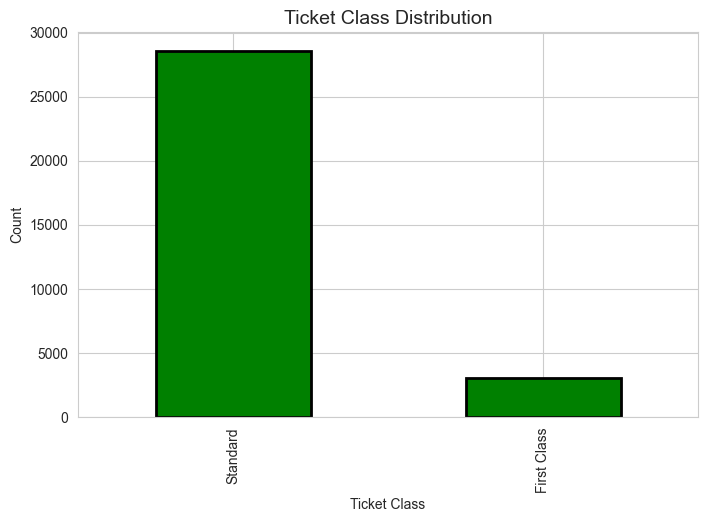

In [33]:
# Univariate Analysis
# Ticket Class Distribution
plt.figure()
df["Ticket_Class"].value_counts().plot.bar(edgecolor="black", linewidth=2, color='green')
plt.title("Ticket Class Distribution", fontsize=14)
plt.xlabel("Ticket Class")
plt.ylabel("Count")
plt.show()


X-axis: Ticket Class (Standard, First Class)
Y-axis: Number of Passengers

Chart Explanation:
This bar chart shows how many passengers fall into each ticket class category. Each bar represents the total count of bookings for that class. The height of the bar indicates popularity. It helps compare demand between classes.

Insight:
Standard class dominates bookings, showing affordability is the key factor for most passengers. Most passengers prefer standard class over first class.

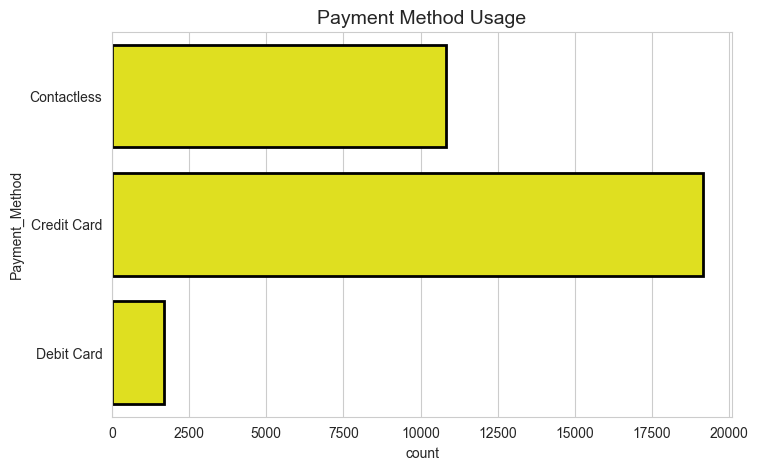

In [34]:
# Payment Method
sns.countplot(y="Payment_Method", data=df, edgecolor="black", linewidth=2, color='yellow')
plt.title("Payment Method Usage", fontsize=14)
plt.show()


X-axis: Number of Transactions
Y-axis: Payment Methods

Chart Explanation:
This horizontal bar chart displays how frequently each payment method is used. Each bar length corresponds to the number of transactions. It highlights customer payment preferences.

Insight:
Digital payments are used more frequently and no Cash transactions are there. Showing a shift toward online transactions.

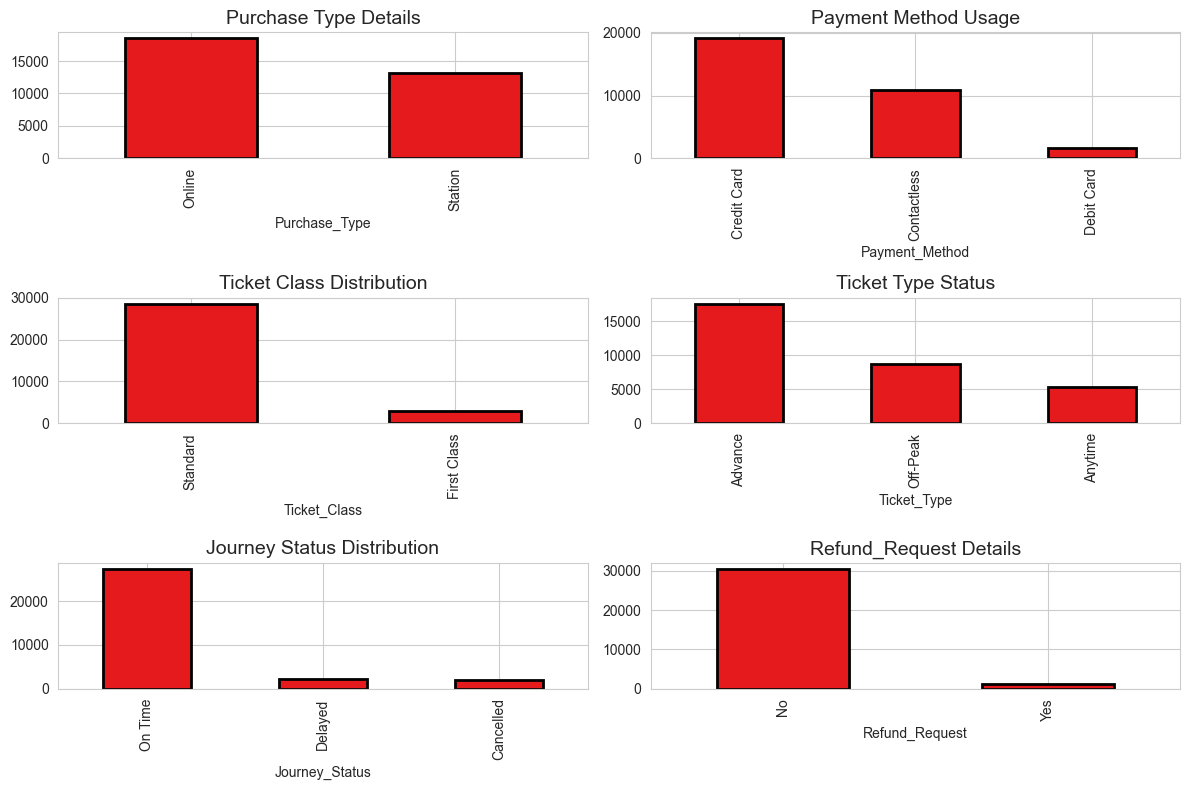

In [35]:
# Univariate Analysis & subplots
fig, axes = plt.subplots(3, 2, figsize=(12,8))

# Plot 1
df["Purchase_Type"].value_counts().plot.bar(edgecolor="black", linewidth=2, ax=axes[0,0])
axes[0,0].set_title("Purchase Type Details", fontsize=14)

# Plot 2
df["Payment_Method"].value_counts().plot.bar(edgecolor="black", linewidth=2, ax=axes[0,1])
axes[0,1].set_title("Payment Method Usage", fontsize=14)

# Plot 3
df["Ticket_Class"].value_counts().plot.bar(edgecolor="black", linewidth=2, ax=axes[1,0])
axes[1,0].set_title("Ticket Class Distribution", fontsize=14)

# Plot 4
df["Ticket_Type"].value_counts().plot.bar(edgecolor="black", linewidth=2, ax=axes[1,1])
axes[1,1].set_title("Ticket Type Status", fontsize=14)

# Plot 5
df["Journey_Status"].value_counts().plot.bar(edgecolor="black", linewidth=2, ax=axes[2,0])
axes[2,0].set_title("Journey Status Distribution", fontsize=14)

# Plot 6
df["Refund_Request"].value_counts().plot.bar(edgecolor="black", linewidth=2, ax=axes[2,1])
axes[2,1].set_title("Refund_Request Details", fontsize=14)

plt.tight_layout()
plt.show()


Overall Figure Explanation

This figure contains 6 bar charts arranged in a 3×2 grid, each representing the distribution of a categorical variable.
Each chart uses value counts, meaning it shows how frequently each category appears in the dataset.
This helps understand customer behavior, ticket preferences, and journey outcomes in one view.
The consistent format makes it easy to compare patterns across variables.


1. Purchase Type Details

X-axis: Purchase Type (Online, Offline)
Y-axis: Number of Transactions

Chart Explanation:
This bar chart shows how tickets are purchased by customers. Each bar represents the count of transactions for each purchase type. It helps identify the preferred booking method.

Insight:
Online purchases dominate over offline(Station) bookings. This reflects increasing digital adoption among users. Customers prefer convenience and accessibility. Railways should focus more on improving online platforms.


2. Payment Method Usage

X-axis: Payment Methods (Credit Card, Contactlss, Debit Card)
Y-axis: Number of Transactions

Chart Explanation:
This chart displays the frequency of different payment methods used. Each bar represents how often a payment method is selected. It highlights customer payment preferences.

Insight:
Digital payment methods are widely used. No Cash transactions are there. This indicates a shift toward cashless economy. Railways can enhance digital payment options.


3. Ticket Class Distribution

X-axis: Ticket Class (Standard, First Class)
Y-axis: Number of Tickets

Chart Explanation:
This chart shows how many tickets are booked in each class. Each bar represents total bookings per class. It helps compare demand across service levels.

Insight:
Standard class has significantly higher bookings. First class is used by fewer passengers. Price sensitivity influences customer choice. Standard class contributes most to volume.


4. Ticket Type Status

X-axis: Ticket Type (Advance, Anytime, Off-Peak)
Y-axis: Number of Tickets

Chart Explanation:
This chart shows the distribution of ticket types purchased. Each bar represents frequency of each ticket type. It reflects customer preferences based on flexibility and pricing.

Insight:
Certain ticket types are more popular than others.
Flexible or cheaper options attract more customers.
Less-used ticket types may need promotion.
This helps optimize ticket offerings.


5. Journey Status Distribution

X-axis: Journey Status (On Time, Delayed, Cancelled)
Y-axis: Number of Journeys

Chart Explanation:
This chart shows the outcome of journeys. Each bar represents how many journeys fall into each status category. It reflects operational performance.

Insight:
Most journeys are completed on time. Delayed journeys form a smaller portion. Cancellations are minimal. Overall service reliability is good.


6. Refund Request Details

X-axis: Refund Request (Yes / No)
Y-axis: Number of Requests

Chart Explanation:
This chart shows how many customers requested refunds. Each bar represents the count of refund requests.
It helps analyze customer dissatisfaction.

Insight:
Most customers do not request refunds. Refund requests are relatively low. Requests may be linked to delays or cancellations. Majority of journeys are on time. Improving service can further reduce refund cases.


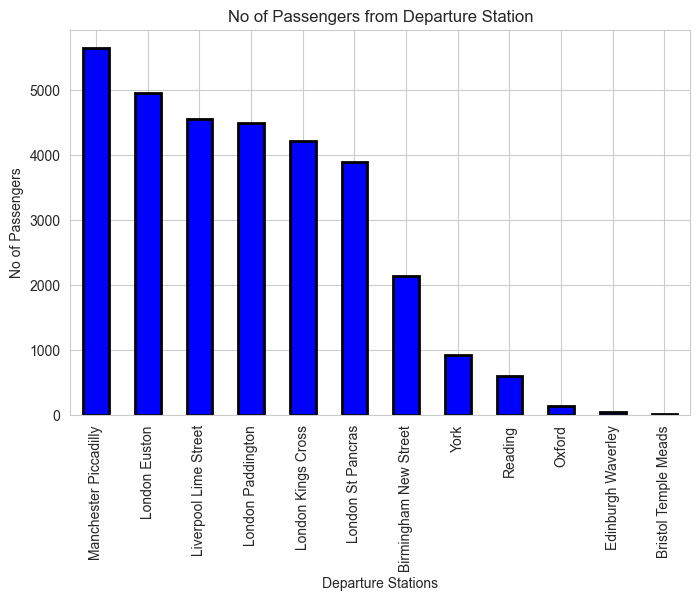

In [36]:
# Bivariate Analysis
# Departure Station vs Price
plt.figure()
df.groupby("Departure_Station")["Transaction_ID"].count().sort_values(ascending=False).plot.bar(color="blue", edgecolor="black", linewidth=2)
plt.title("No of Passengers from Departure Station")
plt.xlabel("Departure Stations")
plt.ylabel("No of Passengers")
plt.show()


X-axis: Departure Stations
Y-axis: Number of Passengers

Chart Explanation
This bar chart shows the total number of passengers departing from each station. Each bar represents a station, and its height indicates the passenger count. The stations are sorted in descending order, so the busiest stations appear first.

Insights 
A few stations have significantly higher passenger counts, indicating major travel hubs. These high-demand stations handle the majority of passenger traffic. Railway authorities can focus on busy stations to optimize operations and services.

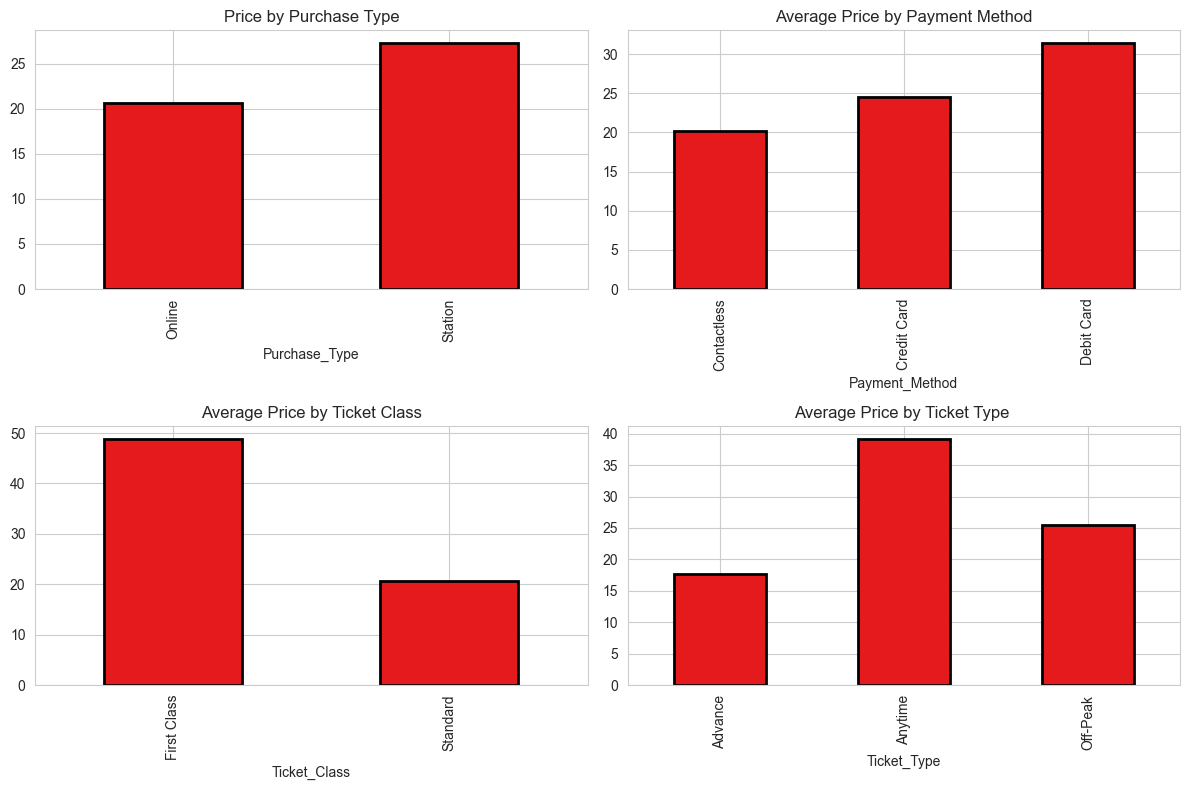

In [37]:
# Bivariate Analysis & subplots
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Plot 1
df.groupby("Purchase_Type")["Ticket_Price"].mean().plot.bar(edgecolor="black", linewidth=2, ax=axes[0,0])
axes[0,0].set_title("Price by Purchase Type")

# Plot 2
df.groupby("Payment_Method")["Ticket_Price"].mean().plot.bar(edgecolor="black", linewidth=2, ax=axes[0,1])
axes[0,1].set_title("Average Price by Payment Method")

# Plot 3
df.groupby("Ticket_Class")["Ticket_Price"].mean().plot.bar(edgecolor="black", linewidth=2, ax=axes[1,0])
axes[1,0].set_title("Average Price by Ticket Class")

# Plot 4
df.groupby("Ticket_Type")["Ticket_Price"].mean().plot.bar(edgecolor="black", linewidth=2, ax=axes[1,1])
axes[1,1].set_title("Average Price by Ticket Type ")

plt.tight_layout()
plt.show()

Overall Figure Explanation

This figure contains 4 bar charts (2×2 layout) showing how ticket price varies across different categorical variables.
Each chart uses groupby mean, so it represents average ticket price rather than count.
This helps identify which factors influence pricing.
The subplot layout allows easy comparison between variables.

1. Price by Purchase Type
X-axis: Purchase Type (Online, Offline)
Y-axis: Average Ticket Price

Chart Explanation:
This bar chart shows the average ticket price for each purchase type. Each bar represents the mean price of tickets bought through a specific channel. It helps compare pricing between online and offline purchases.

Insight:
Prices are generally similar for both purchase types. Any slight variation may be due to service charges or offers. Online purchases are more common but not significantly cheaper. Pricing strategy remains consistent across channels.

2. Average Price by Payment Method
X-axis: Payment Method (Credit Card, Contactlss, Debit Card)
Y-axis: Average Ticket Price

Chart Explanation:
This chart shows how average ticket price varies with payment method.Each bar represents the mean price paid using a specific payment option. It helps identify whether pricing differs by transaction type.

Insight:
There is very little variation in prices across payment methods. This indicates pricing is independent of how customers pay. No major discounts or charges are linked to payment type. Payment methods mainly impact convenience, not cost.

3. Average Price by Ticket Class
X-axis: Ticket Class (Standard, First Class)
Y-axis: Average Ticket Price

Chart Explanation:
This chart compares average prices between ticket classes. Each bar shows the mean cost of tickets within that class. It highlights pricing differences based on service level.

Insight:
First-class tickets are significantly more expensive. Standard class offers lower and more affordable pricing.
This reflects clear service-based pricing differentiation. Customers pay more for comfort and premium services.

4. Average Price by Ticket Type
X-axis: Ticket Type (Advance, Anytime, Off-Peak)
Y-axis: Average Ticket Price

Chart Explanation:
This chart shows how average ticket price varies across ticket types. Each bar represents the mean price for a specific ticket category. It helps understand pricing based on flexibility and timing.

Insight:
Some ticket types have higher average prices than others. Flexible tickets (e.g., Anytime) tend to be more expensive. Advance or restricted tickets are usually cheaper. Customers trade flexibility for cost savings.

<Figure size 800x500 with 0 Axes>

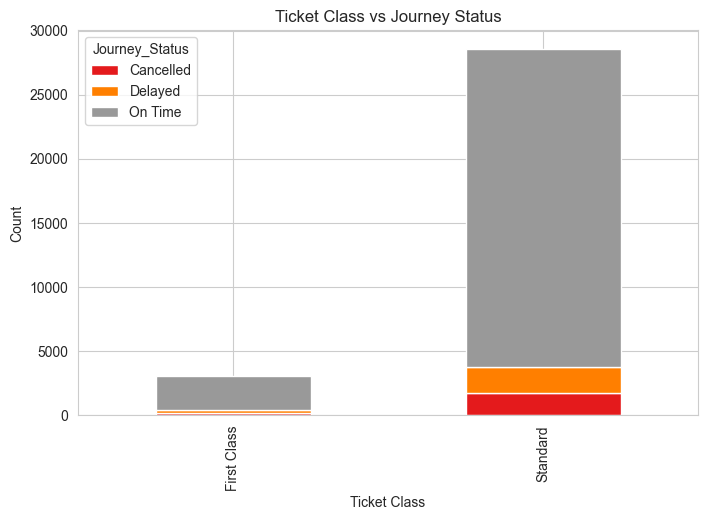

In [38]:
# Multivariate Analysis
# Stacked Bar Chart – Ticket Class vs Journey Status
plt.figure()
pd.crosstab(df["Ticket_Class"], df["Journey_Status"]).plot(kind='bar', stacked=True, colormap='Set1')
plt.title("Ticket Class vs Journey Status")
plt.xlabel("Ticket Class")
plt.ylabel("Count")
plt.show()

X-axis: Ticket Class
Y-axis: Count of Journeys
Legend: Journey Status

Chart Explanation:
This stacked bar chart shows distribution of journey status within each class.
Each bar is divided into segments representing status categories.
It allows comparison within and across classes.

Insight:
Standard class has more journeys overall. Both classes experience delays. On-time journeys dominate each class. Class type has limited impact on delays.

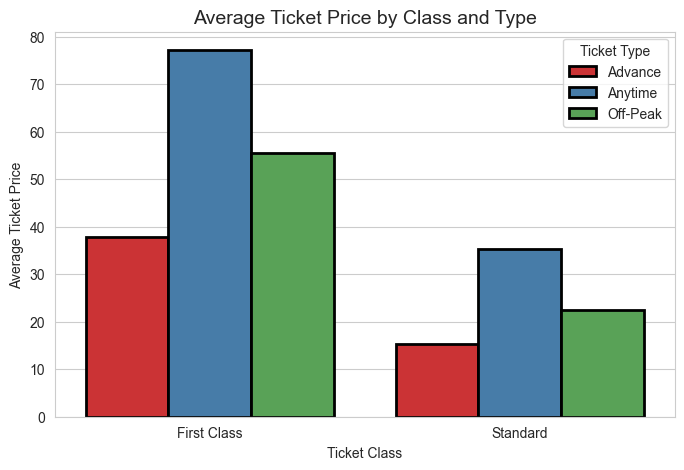

In [39]:
# Average Ticket Price by Class and Type
group = df.groupby(["Ticket_Class", "Ticket_Type"])["Ticket_Price"].mean().reset_index()

sns.barplot(x="Ticket_Class", y="Ticket_Price", hue="Ticket_Type", data=group, edgecolor="black", linewidth=2)

plt.title("Average Ticket Price by Class and Type", fontsize=14)
plt.xlabel("Ticket Class")
plt.ylabel("Average Ticket Price")
plt.legend(title="Ticket Type")
plt.show()

X-axis:Represents Ticket Class (Standard, First Class)
Each category shows a different level of service and comfort
Y-axis:
Represents Average Ticket Price, calculated using groupby() mean values.

Chart Description:
This is a grouped bar chart where each ticket class is divided further by ticket type using different colors.
Each bar represents the average price for a specific combination of ticket class and ticket type.

Insight:
First-class tickets consistently show higher average prices across all ticket types.
Within each class, certain ticket types are priced higher, indicating service or flexibility differences.
This chart helps identify which combinations generate higher revenue potential.

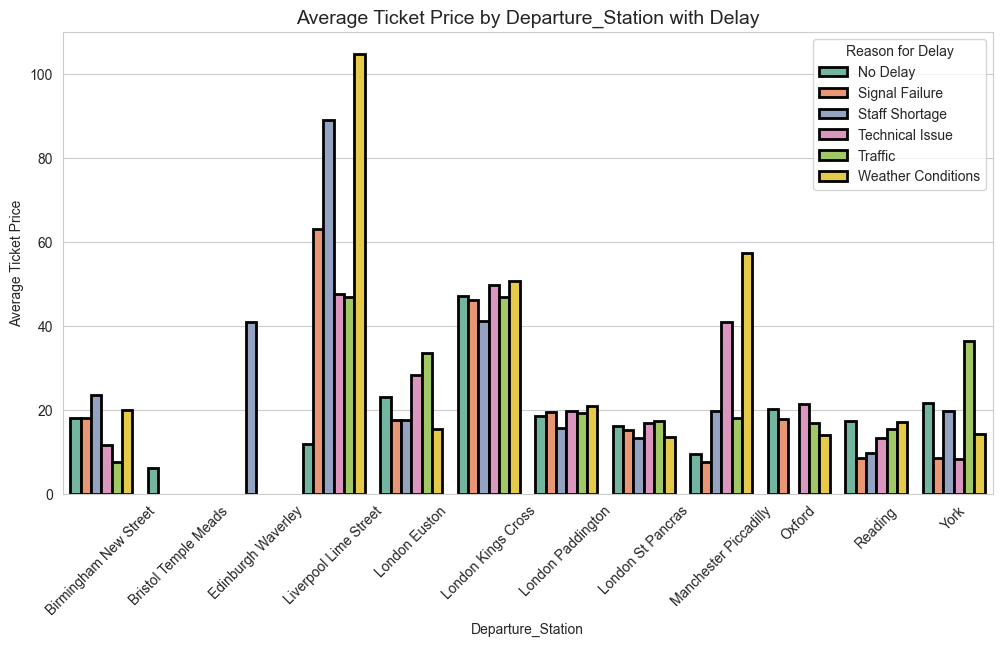

In [40]:
# Average Ticket Price by Departure_Station with Delay
group1 = df.groupby(["Departure_Station", "Reason_for_Delay"])["Ticket_Price"].mean().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x="Departure_Station", y="Ticket_Price", hue="Reason_for_Delay", data=group1, palette="Set2", edgecolor="black", linewidth=2)

plt.title("Average Ticket Price by Departure_Station with Delay", fontsize=14)
plt.xlabel("Departure_Station")
plt.ylabel("Average Ticket Price")
plt.legend(title="Reason for Delay")
plt.xticks(rotation=45)
plt.show()

X-axis: Departure Station
Y-axis: Average Ticket Price
Legend (Hue): Reason for Delay

Chart Explanation

This grouped bar chart shows the average ticket price across different departure stations, further divided by reason for delay.This allows comparison within a station (between delay reasons) and across stations.
It is useful for understanding how pricing varies along with operational conditions.

Insights
Ticket prices vary across departure stations, indicating location-based pricing differences.
Within the same station, price variation across delay reasons is generally small.
This suggests that ticket pricing is not strongly influenced by delay causes.
Some stations consistently show higher average prices, indicating premium routes or demand.
Delay reasons mainly impact operations, while pricing remains relatively stable.

Mostly no delay, but if delay weather-related issues are common causes of delays.

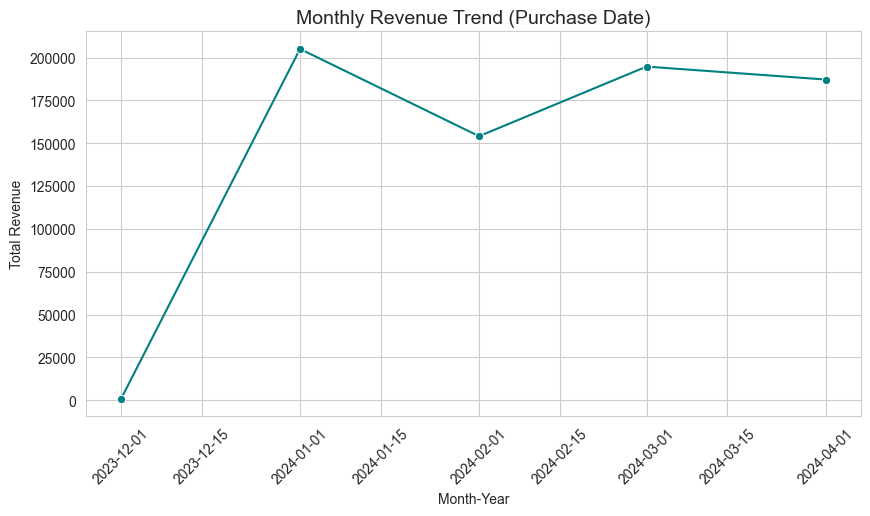

In [41]:
# Monthly Revenue Trend (Purchase Date)

df["Purchase_Month_Year"] = df["Date_of_Purchase"].dt.to_period('M').astype(str)

# Groupby total revenue
monthly_revenue = df.groupby("Purchase_Month_Year")["Ticket_Price"].sum().reset_index()

# Sort properly
monthly_revenue["Purchase_Month_Year"] = pd.to_datetime(monthly_revenue["Purchase_Month_Year"])
monthly_revenue = monthly_revenue.sort_values("Purchase_Month_Year")

# Plot
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.figure(figsize=(10,5))

sns.lineplot(data=monthly_revenue,
             x='Purchase_Month_Year',
             y='Ticket_Price',
             marker='o',
             color='teal')

plt.title("Monthly Revenue Trend (Purchase Date)", fontsize=14)
plt.xlabel("Month-Year")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

X-axis: Month-Year, Represents timeline based on purchase date
Y-axis: Total Revenue (Sum of Ticket Prices)

Chart Explanation
This line chart shows how total ticket revenue changes over time based on purchase date. Each point represents the total revenue for a specific month-year combination. The line connects values to highlight trends and fluctuations. Markers make it easier to identify individual data points. It is useful for analyzing long-term trends and seasonal patterns.

Insights
Revenue shows fluctuations across different months and years. Certain periods may show higher revenue due to peak travel demand. Lower revenue periods indicate reduced booking activity. Trends help identify growth or decline over time. This analysis supports forecasting and strategic planning.

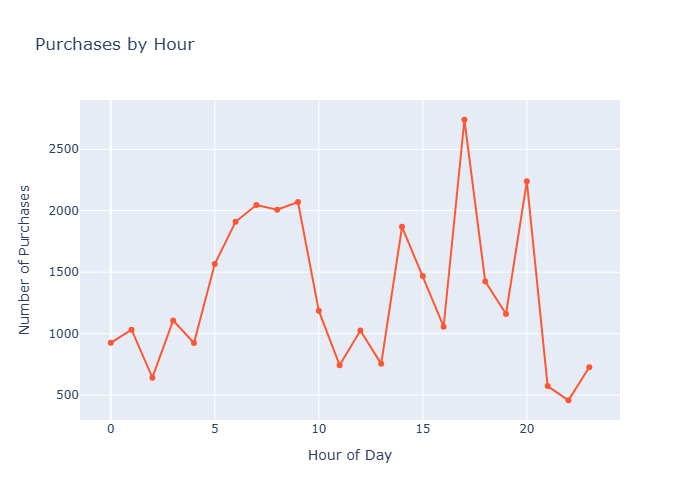

In [42]:
#Interactive Line Chart – Purchases by Hour
df["Purchase_Hour"] = pd.to_datetime(df["Time_of_Purchase"]).dt.hour
hourly = df.groupby("Purchase_Hour").size().reset_index(name='count')

fig = px.line(hourly, x='Purchase_Hour', y='count', markers=True,
              title="Purchases by Hour", color_discrete_sequence=["#FF5733"])

fig.update_layout(xaxis_title="Hour of Day",
                  yaxis_title="Number of Purchases")

fig.show()


X-axis: Hour of the day (0–23)
Y-axis: Number of ticket purchases

Chart Description:
This interactive line chart shows how ticket bookings vary throughout the day.
Markers highlight each data point, making it easy to observe peaks and drops.
Hovering displays exact values for better understanding. It helps identify time-based trends in purchasing behavior.

Insight:
Booking activity peaks during daytime hours. Late night and early morning show lower activity.
This reflects typical user behavior patterns. Railways can optimize system performance during peak hours.

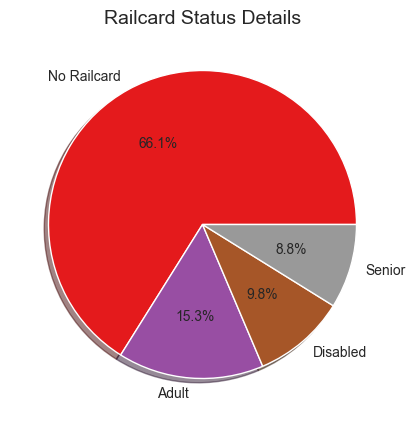

In [43]:
# Pie Chart – Railcard Status Distribution

df["Railcard_Status"].value_counts().plot(kind='pie', autopct='%1.1f%%', colormap='Set1', shadow=True)

plt.title("Railcard Status Details", fontsize=14)
plt.ylabel("")
plt.show()

X-axis & Y-axis : Not applicable (Pie charts do not use an X-axis or a Y-axis)
Pie charts use:Slices (categories) → Railcard Status (Yes (Senior, Disabled, Adult) / No)
Size of slice → Percentage share of each category

Chart Explanation
This pie chart represents the distribution of passengers based on their railcard status.
The percentage labels (autopct) make it easy to understand the exact contribution of each group.

Insights
A larger portion of passengers may not have a railcard, indicating general ticket purchases without discounts.
A smaller segment represents passengers using railcards, showing adoption of discount schemes.
Railcards help reduce ticket prices, making travel more affordable for certain groups.

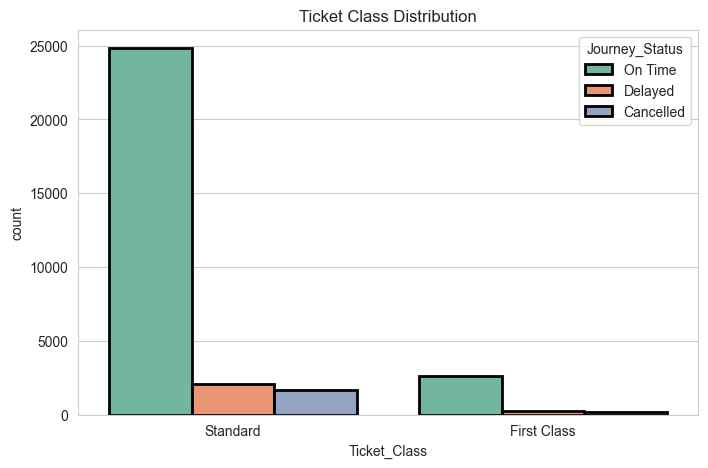

In [44]:
# Count Plot with Hue (Journey Status)
plt.figure()
sns.countplot(data=df, x="Ticket_Class", hue="Journey_Status", edgecolor="black", linewidth=2)
plt.title("Ticket Class Distribution")
plt.show()

X-axis: Ticket Class
Y-axis: Count
Legend: Journey Status

Chart Explanation:
This grouped bar chart compares journey outcomes across ticket classes. It helps identify if class affects delays.

Insight:
Both classes experience delays, but distribution is similar.

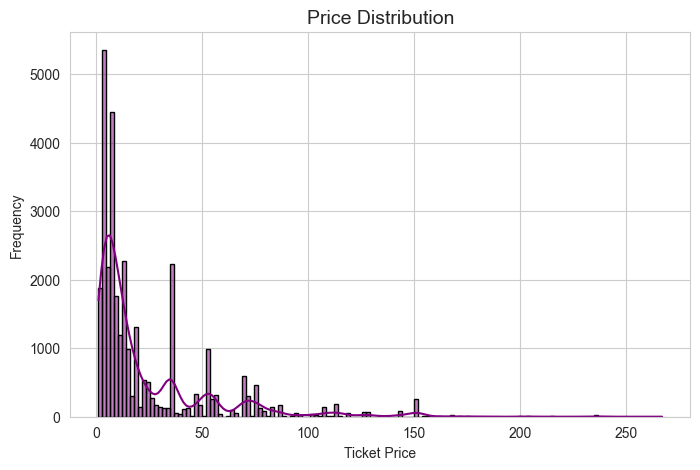

In [45]:
# Histogram – Price Distribution
sns.histplot(df["Ticket_Price"], kde=True, color='purple', edgecolor="black", linewidth=1)
plt.title("Price Distribution", fontsize=14)
plt.xlabel("Ticket Price")
plt.ylabel("Frequency")
plt.show()

X-axis: Ticket Price
Y-axis: Frequency (Number of Tickets)

Chart Explanation:
This histogram shows how ticket prices are distributed across all bookings. The bars represent frequency within price ranges. The KDE line shows the density trend.

Insight:
Most ticket prices fall within a moderate range, with fewer expensive tickets. The distribution is slightly skewed depending on premium bookings. This indicates a balanced pricing structure.

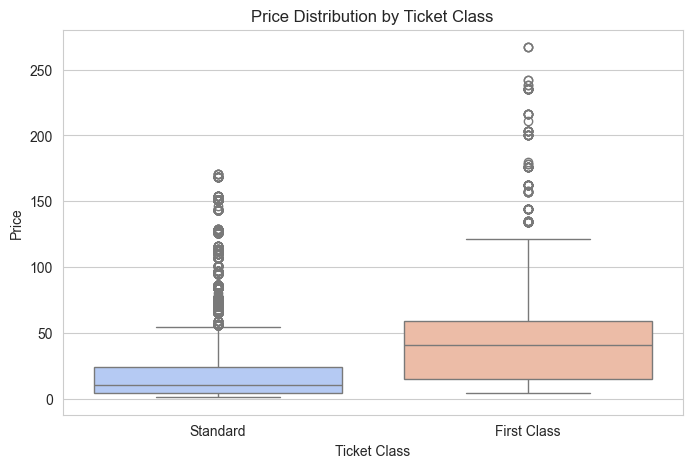

In [46]:
# Box Plot – Price by Ticket Class
plt.figure()
sns.boxplot(data=df, x="Ticket_Class", y="Ticket_Price", palette='coolwarm')
plt.title("Price Distribution by Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Price")
plt.show()

X-axis: Ticket Class
Y-axis: Ticket Price

Chart Explanation:
This boxplot shows price distribution for each class. It highlights median, quartiles, and outliers.
Boxes represent interquartile range. Whiskers show spread of data.

Insight:
First-class tickets have higher median prices. Standard class prices are lower and more compact.
Outliers indicate premium bookings. Pricing variability differs between classes.

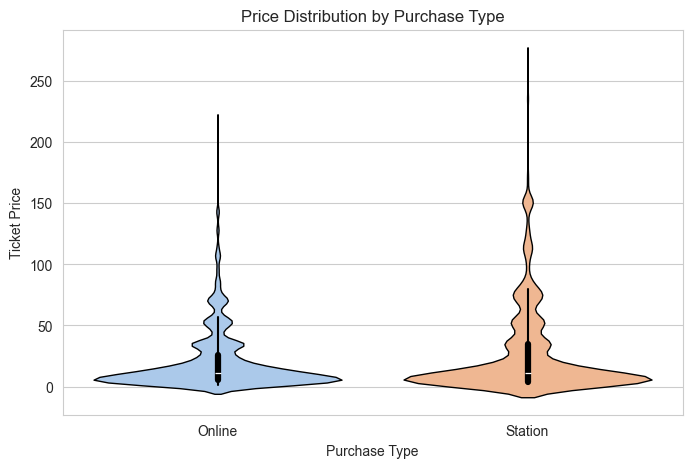

In [47]:
# Violin Plot – Price Distribution
plt.figure()
sns.violinplot(data=df, x="Purchase_Type", y="Ticket_Price", palette='pastel', edgecolor="black", linewidth=1)
plt.title("Price Distribution by Purchase Type")
plt.xlabel("Purchase Type")
plt.ylabel("Ticket Price")
plt.show()

X-axis: Purchase Type (Online, Station)
Y-axis: Ticket Price

Chart Explanation:
This violin plot shows the distribution of ticket prices for each purchase type. Width represents density of values. The inner part (line/box) shows the median and spread of the data. It combines boxplot and density plot. Shows spread and concentration clearly.

Insight:
Ticket prices for both online and offline purchases show a similar distribution pattern. Most prices are concentrated within a common range, indicating consistent pricing. Ticket prices for both online and offline purchases show a similar distribution pattern. Most prices are concentrated within a common range, indicating consistent pricing.

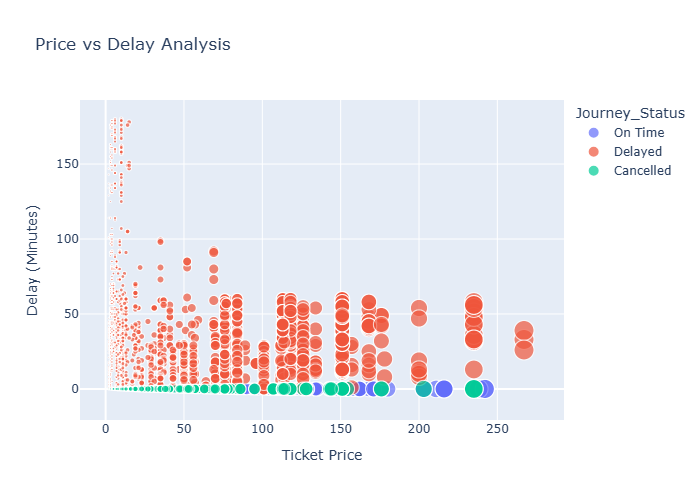

In [48]:
# Interactive Scatter Plot – Price vs Delay
fig = px.scatter(df, x="Ticket_Price", y="Total_Late_Time_Minutes", color="Journey_Status",
                 size="Ticket_Price", hover_data=["Ticket_Class"], title="Price vs Delay Analysis")

fig.update_layout(xaxis_title="Ticket Price",
                  yaxis_title="Delay (Minutes)")

fig.show()

X-axis: Ticket Price
Y-axis: Delay (Minutes)

Chart Description:
This scatter plot shows the relationship between ticket price and delay.
Each point represents a journey, with size indicating ticket price.
Color differentiates journey status. Hover feature provides additional details for deeper analysis.

Insight:
There is no strong relationship between price and delay. Both high and low-priced tickets experience delays.
Delayed journeys are spread across all price ranges. This indicates delay is independent of pricing.

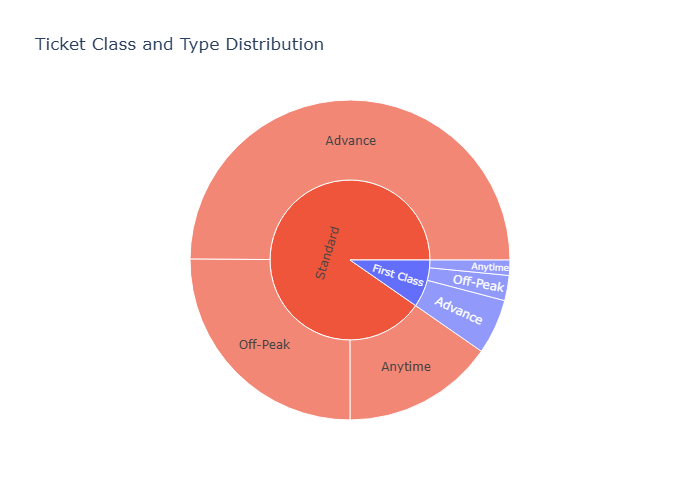

In [49]:
# Interactive Sunburst Chart – Ticket Class & Type
fig = px.sunburst(df,
                  path=["Ticket_Class", "Ticket_Type"],
                  title="Ticket Class and Type Distribution",
                  color="Ticket_Class")

fig.show()

X-axis: Hierarchical categories (Ticket Class → Ticket Type)
Y-axis: Not applicable (hierarchical representation)

Chart Description:
This sunburst chart visualizes hierarchical relationships between ticket class and ticket type.
Inner circle represents ticket class, outer ring shows ticket types.
Size of segments indicates proportion. It gives a layered understanding of ticket distribution.

Insight:
Standard class dominates overall ticket distribution. Certain ticket types are more popular within each class.
The hierarchy clearly shows customer preferences. It helps in identifying key revenue-driving segments.

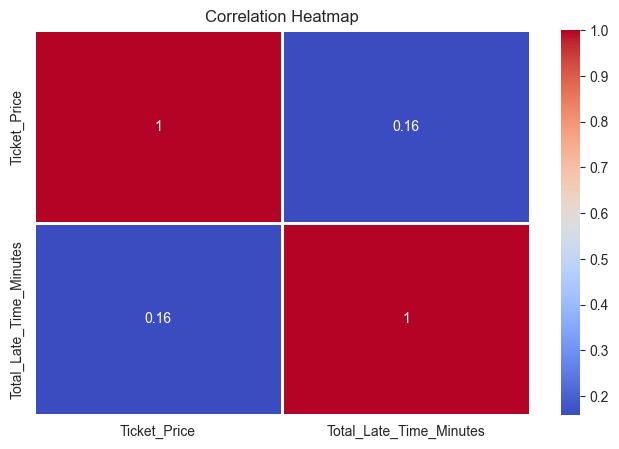

In [50]:
# Heatmap – Correlation
plt.figure()
corr = df[["Ticket_Price", "Total_Late_Time_Minutes"]].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=1)
plt.title("Correlation Heatmap")
plt.show()

X-axis: Numerical Variables
Y-axis: Numerical Variables

Chart Explanation:
This heatmap shows correlation between numerical variables. Colors represent strength of relationship.
Values range from -1 to +1. Annotations display exact correlation values.

Insight:
Correlation between price and delay is very weak. This means price does not influence delay.
Variables behave independently. No strong linear relationship exists.

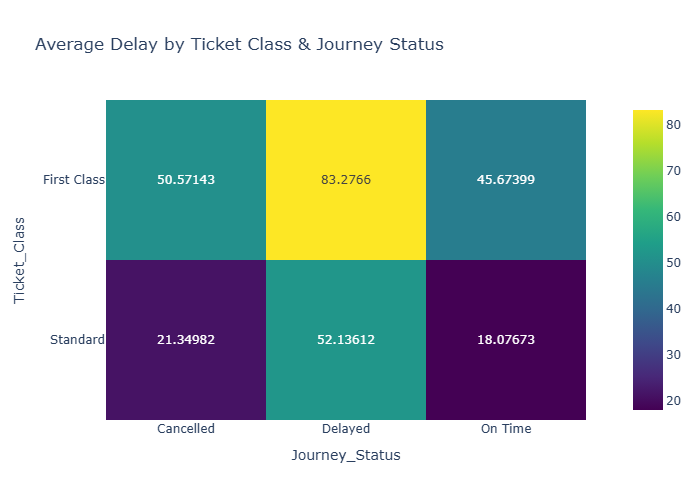

In [51]:

# Interactive Heatmap – Delay by Class & Status
pivot = df.pivot_table(values="Ticket_Price", index="Ticket_Class",
                       columns="Journey_Status", aggfunc='mean').reset_index()

fig = px.imshow(pivot.set_index("Ticket_Class"),
                text_auto=True, 
                color_continuous_scale='Viridis',
                title="Average Delay by Ticket Class & Journey Status")

fig.show()

X-axis: Journey Status
Y-axis: Ticket Class

Chart Description:
This heatmap shows average delay across ticket class and journey status.
Color intensity represents delay magnitude. Darker colors indicate higher delays.
Values are displayed inside each cell for clarity.

Insight:
Delayed journeys show significantly higher delay values.
On-time journeys have near-zero delay. Ticket class has minimal impact on delay.
Journey status is the main factor affecting delay.

### Final Insights


#### Revenue Contribution by Ticket Class
Standard class generates the highest total revenue due to a larger number of passengers, even though first-class tickets are priced higher.


#### Revenue & Time-Based Trends
Revenue varies across different months and time periods, showing seasonal patterns. Certain months generate higher revenue due to increased travel demand. Hourly analysis shows that most bookings occur during daytime.
Lower activity is observed during late night and early morning. These trends can help in demand forecasting and resource planning.


#### Ticket Pricing Strategy
Ticket price is mainly influenced by ticket class and ticket type. First-class tickets are significantly more expensive than standard tickets. Flexible ticket types (like Anytime) have higher prices compared to restricted ones. Purchase type and payment method do not significantly affect pricing. This shows a consistent and structured pricing model across the system.


#### Delay Impact on Journey Status
Most journeys are completed on time, indicating good operational efficiency. Delayed journeys have significantly higher average late times, while on-time journeys show near-zero delay, confirming the reliability of journey status classification. Delayed journeys exist but form a smaller portion of total trips. There is no strong relationship between ticket price and delay. Delay issues are more operational than pricing-related.


#### Passenger Distribution & Travel Demand
Certain routes show consistently higher passenger volume, indicating major travel corridors and high-demand railway connections. A few departure stations handle major passenger traffic, acting as key travel hubs.
Other stations show comparatively lower usage. High-demand routes contribute significantly to revenue.
Understanding this helps optimize route planning and scheduling.


#### Refund & Customer Satisfaction
Refund requests are relatively low compared to total journeys. Most passengers complete journeys without issues. Refunds are likely associated with delays or cancellations. This indicates overall customer satisfaction is reasonably high. However, improving delay management can further reduce refund cases.


#### Railcard Usage & Customer Segmentation
A significant portion of passengers do not use railcards. Railcard users represent a smaller but important segment. Railcards help reduce travel costs for specific groups. There is an opportunity to increase adoption through awareness and offers. This can improve customer loyalty and repeat usage.


#### Payment Method Analysis
Digital payment methods dominate transactions, contributing the majority of total revenue. Nobody use cash transaction. This highlights the importance of improving online systems and user experience. Digital adoption plays a key role in modern railway services.


#### Delay Causes
Operational and external factors (like weather or technical issues) are the primary contributors to delays.


#### Multivariate Analysis Insights
Combining multiple variables shows that pricing remains stable across operational factors. Departure station influences pricing more than delay reasons. Delay reasons do not significantly impact ticket price. This confirms that pricing is demand- and service-based rather than condition-based.Multi-variable analysis provides deeper understanding of system behavior.

## Conclusion

This project analyzed UK train ride data to understand passenger behavior, pricing patterns and operational performance using Python-based data analytics techniques. The findings show that most customers prefer online booking and digital payments, highlighting the importance of digital platforms. Ticket pricing is mainly influenced by ticket class and ticket type, while payment method and purchase type have minimal impact. Time-based analysis revealed clear daily and monthly trends, helping identify peak demand periods. Passenger distribution is concentrated in a few major stations, indicating key travel hubs. Journey performance is generally efficient, with most trips on time and relatively low refund requests. Overall, the analysis demonstrates how data-driven insights can support better decision-making, improve customer experience, and optimize railway operations.